# Phân tích Hiệu suất Chuyến bay Đúng giờ trên DataBricks
Notebook này cung cấp phân tích về Hiệu suất Chuyến bay Đúng giờ (On-Time) và Trễ (Delay) chuyến với thư viện NetworkX trên DataBricks.

Nguồn Dữ liệu:
* [OpenFlights: Dữ liệu sân bay, hãng hàng không và tuyến đường](http://openflights.org/data.html)
* [Bộ Giao thông Vận tải Hoa Kỳ: Cục Thống kê Giao thông (TranStats)](http://www.transtats.bts.gov/DL_SelectFields.asp?Table_ID=236&DB_Short_Name=On-Time)
 * Dữ liệu được sử dụng ở đây được trích xuất từ US DOT:BTS từ ngày 1/1/2014 đến 31/3/2014*


## Chuẩn bị

#### Trích xuất thông tin Sân bay (Airports) và Trễ chuyến (Tripdelays)

In [0]:
# Đường dẫn
tripdelaysFilePath = "/databricks-datasets/flights/departuredelays.csv" # Dữ liệu trễ chuyến bay
airportsnaFilePath = "/databricks-datasets/flights/airport-codes-na.txt" # Dữ liệu sân bay

# Lấy dữ liệu sân bay
airportsna = spark.read.format("com.databricks.spark.csv").options(header='true', inferschema='true', delimiter='\t').load(airportsnaFilePath)
airportsna.registerTempTable("airports_na")

# Lấy dữ liệu trễ chuyến
departureDelays = spark.read.format("com.databricks.spark.csv").options(header='true').load(tripdelaysFilePath)
departureDelays.registerTempTable("departureDelays")

# Mã IATA khả dụng từ bộ dữ liệu mẫu trễ chuyến
tripIATA = spark.sql("select distinct iata from (select distinct origin as iata from departureDelays union all select distinct destination as iata from departureDelays) a")
tripIATA.registerTempTable("tripIATA")

# Chỉ bao gồm các sân bay có ít nhất một chuyến bay từ bộ dữ liệu departureDelays
airports = spark.sql("select f.IATA, f.City, f.State, f.Country from airports_na f join tripIATA t on t.IATA = f.IATA")
airports.registerTempTable("airports")

/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/dataframe.py:2262: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


#### Xây dựng DataFrame: departureDelays_geo

In [0]:
#  Lấy các thuộc tính chính như Ngày bay, trễ, khoảng cách và thông tin sân bay (Điểm đi, Điểm đến)  
departureDelays_geo = spark.sql("select cast(f.date as int) as tripid, cast(concat(concat(concat(concat(concat(concat('2014-', concat(concat(substr(cast(f.date as string), 1, 2), '-')), substr(cast(f.date as string), 3, 2)), ' '), substr(cast(f.date as string), 5, 2)), ':'), substr(cast(f.date as string), 7, 2)), ':00') as timestamp) as `localdate`, cast(f.delay as int), cast(f.distance as int), f.origin as src, f.destination as dst, o.city as city_src, d.city as city_dst, o.state as state_src, d.state as state_dst from departuredelays f join airports o on o.iata = f.origin join airports d on d.iata = f.destination") 

# Đăng ký bảng tạm
departureDelays_geo.registerTempTable("departureDelays_geo")

# Lưu cache và đếm
departureDelays_geo.count()

/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/dataframe.py:2262: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


1361141


## Xây dựng Đồ thị
Bây giờ sau khi đã import dữ liệu, chúng ta sẽ cần xây dựng đồ thị. Để làm điều này, chúng ta sẽ làm hai việc: xây dựng cấu trúc của các đỉnh (vertices hay nodes) và xây dựng cấu trúc của các cạnh (edges).
* Đổi tên mã sân bay IATA thành **id** trong Bảng Vertices
* Sân bay bắt đầu và kết thúc thành **src** và **dst** cho Bảng Edges (chuyến bay)

Đây là các quy ước đặt tên bắt buộc cho vertices và edges.


In [0]:
# Tải thư viện Graphframes ở đây
%pip install graphframes

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from pyspark.sql.functions import *
from graphframes import *

# Tạo Vertices (sân bay) và Edges (chuyến bay)
tripVertices = airports.withColumnRenamed("IATA", "id").distinct()
tripEdges = departureDelays_geo.select("tripid", "delay", "src", "dst", "city_dst", "state_dst")

In [0]:
# Vertices: Các đỉnh của đồ thị là các sân bay
display(tripVertices.limit(10))


id,City,State,Country
FAR,Fargo,ND,USA
ABQ,Albuquerque,NM,USA
JFK,New York,NY,USA
DFW,Dallas,TX,USA
HSV,Huntsville,AL,USA
VLD,Valdosta,GA,USA
BDL,Hartford,CT,USA
BET,Bethel,AK,USA
MGM,Montgomery,AL,USA
LBB,Lubbock,TX,USA


In [0]:
# Edges: Các cạnh của đồ thị là các chuyến bay giữa các sân bay
display(tripEdges.limit(10))

tripid,delay,src,dst,city_dst,state_dst
1011305,2,DFW,HNL,"Honolulu, Oahu",HI
1011200,5,DFW,OGG,"Kahului, Maui",HI
1011840,18,DFW,SLC,Salt Lake City,UT
1011120,10,DFW,DTW,Detroit,MI
1011645,-1,DFW,PIT,Pittsburgh,PA
1011155,16,DFW,SAN,San Diego,CA
1011725,9,DFW,MIA,Miami,FL
1011055,40,DFW,JFK,New York,NY
1010545,-7,DFW,ORD,Chicago,IL
1010855,-2,DFW,STL,St. Louis,MO


In [0]:
# Tải thư viện Networkx tại đây
%pip install networkx

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import networkx as nx

# Xây dựng đồ thị NetworkX thay thế cho GraphFrames (không hoạt động trên serverless)
# Tạo đồ thị có hướng NetworkX cho toàn bộ dữ liệu chuyến bay
tripGraph_nx = nx.DiGraph()

# Thêm các đỉnh (sân bay)
vertices_list = tripVertices.collect()
for row in vertices_list:
    tripGraph_nx.add_node(row['id'], 
                          City=row['City'], 
                          State=row['State'], 
                          Country=row['Country'])

# Thêm các cạnh (chuyến bay) - lấy mẫu trước để tránh thu thập 1.3M dòng
print(f"Adding {tripEdges.count()} edges to NetworkX graph...")
edges_list = tripEdges.collect()
for row in edges_list:
    tripGraph_nx.add_edge(row['src'], row['dst'],
                         tripid=row['tripid'],
                         delay=row['delay'],
                         city_dst=row['city_dst'],
                         state_dst=row['state_dst'])

# Tạo lớp wrapper để duy trì khả năng tương thích với các cell dưới sử dụng .vertices và .edges
class GraphWrapper:
    """Wrapper cung cấp giao diện giống GraphFrame cho đồ thị NetworkX"""
    def __init__(self, nx_graph, vertices_df, edges_df):
        self.nx_graph = nx_graph  # Đồ thị NetworkX cho các thuật toán đồ thị
        self.vertices = vertices_df  # Spark DataFrame gốc
        self.edges = edges_df  # Spark DataFrame gốc
        
tripGraph = GraphWrapper(tripGraph_nx, tripVertices, tripEdges)

# Xây dựng tripGraphPrime với tập con dữ liệu cạnh
tripEdgesPrime = departureDelays_geo.select("tripid", "delay", "src", "dst")
tripGraph_prime_nx = nx.DiGraph()

# Thêm các đỉnh vào đồ thị prime
for row in vertices_list:
    tripGraph_prime_nx.add_node(row['id'], 
                                City=row['City'], 
                                State=row['State'], 
                                Country=row['Country'])

# Thêm các cạnh cho đồ thị prime
print(f"Adding {tripEdgesPrime.count()} edges to prime graph...")
edges_prime_list = tripEdgesPrime.collect()
for row in edges_prime_list:
    tripGraph_prime_nx.add_edge(row['src'], row['dst'],
                                tripid=row['tripid'],
                                delay=row['delay'])

tripGraphPrime = GraphWrapper(tripGraph_prime_nx, tripVertices, tripEdgesPrime)

print(f"\nGraphs created successfully!")
print(f"  tripGraph: {tripGraph_nx.number_of_nodes()} nodes, {tripGraph_nx.number_of_edges()} edges")
print(f"  tripGraphPrime: {tripGraph_prime_nx.number_of_nodes()} nodes, {tripGraph_prime_nx.number_of_edges()} edges")

Adding 1361141 edges to NetworkX graph...
Adding 1361141 edges to prime graph...

Graphs created successfully!
  tripGraph: 279 nodes, 3976 edges
  tripGraphPrime: 279 nodes, 3976 edges


## Truy vấn Đơn giản
Hãy bắt đầu với một tập các truy vấn đồ thị đơn giản để hiểu hiệu suất chuyến bay và trễ chuyến


#### Xác định số lượng sân bay và chuyến bay


In [0]:
print("Số sân bay (Airports): %d" % tripGraph.vertices.count())
print("Số chuyến bay (Trips): %d" % tripGraph.edges.count())


Số sân bay (Airports): 279
Số chuyến bay (Trips): 1361141


#### Xác định thời gian trễ dài nhất trong bộ dữ liệu này


In [0]:
longestDelay = tripGraph.edges.groupBy().max("delay")
display(longestDelay)

max(delay)
1642


#### Xác định số chuyến bay trễ chuyến (delayed) với số chuyến bay đúng giờ / sớm hơn (on-time / early flights)


In [0]:
print(f"On-time / Early Flights: {tripGraph.edges.filter('delay <= 0').count()}")
print(f"Delayed Flights: {tripGraph.edges.filter('delay > 0').count()}")

On-time / Early Flights: 780469
Delayed Flights: 580672


#### Những chuyến bay khởi hành từ SFO nào có khả năng bị chậm trễ đáng kể nhất ?
Lưu ý: độ trễ có thể nhỏ hơn hoặc bằng 0, nghĩa là chuyến bay đã khởi hành đúng giờ hoặc sớm hơn dự kiến


In [0]:
tripGraph.edges\
  .filter("src = 'SFO' and delay > 0")\
  .groupBy("src", "dst")\
  .avg("delay")\
  .sort(desc("avg(delay)"))


DataFrame[src: string, dst: string, avg(delay): double]

In [0]:
display('Số chuyến bay khởi hành từ SFO có khả năng bị trễ: ',tripGraph.edges.filter("src = 'SFO' and delay > 0").groupBy("src", "dst").avg("delay").count())
display(tripGraph.edges.filter("src = 'SFO' and delay > 0").groupBy("src", "dst").avg("delay").sort(desc("avg(delay)")))


'Số chuyến bay khởi hành từ SFO có khả năng bị trễ: '

72

src,dst,avg(delay)
SFO,OKC,59.073170731707314
SFO,JAC,57.13333333333333
SFO,COS,53.976190476190474
SFO,OTH,48.09090909090909
SFO,SAT,47.625
SFO,MOD,46.80952380952381
SFO,SUN,46.723404255319146
SFO,CIC,46.72164948453608
SFO,ABQ,44.8125
SFO,ASE,44.285714285714285


#### Những điểm đến nào thường xuyên bị chậm chuyến?


In [0]:
# After displaying tripDelays, use Plot Options to set `state_dst` as a Key.
tripDelays = tripGraph.edges.filter("delay > 0")
display(tripDelays)


tripid,delay,src,dst,city_dst,state_dst
1011305,2,DFW,HNL,"Honolulu, Oahu",HI
1011200,5,DFW,OGG,"Kahului, Maui",HI
1011840,18,DFW,SLC,Salt Lake City,UT
1011120,10,DFW,DTW,Detroit,MI
1011155,16,DFW,SAN,San Diego,CA
1011725,9,DFW,MIA,Miami,FL
1011055,40,DFW,JFK,New York,NY
1010840,6,DFW,SNA,Orange County,CA
1011035,7,DFW,ONT,Ontario,CA
1011010,35,DFW,DEN,Denver,CO


#### Điểm đến nào thường có trễ đáng kể khi khởi hành từ SEA


In [0]:
# Các tiểu bang có tổng thời gian trễ dài nhất (với thời gian trễ riêng lẻ > 100 phút) (xuất phát: Seattle)
display(tripGraph.edges.filter("src = 'SEA' and delay > 100"))


tripid,delay,src,dst,city_dst,state_dst
3301400,277,SEA,DFW,Dallas,TX
3180935,135,SEA,LGB,Long Beach,CA
3191020,139,SEA,SMF,Sacramento,CA
3311440,101,SEA,SFO,San Francisco,CA
3281750,125,SEA,SLC,Salt Lake City,UT
3181417,127,SEA,ORD,Chicago,IL
2091150,232,SEA,FAT,Fresno,CA
3130720,117,SEA,KTN,Ketchikan,AK
3130725,174,SEA,ONT,Ontario,CA
3301728,108,SEA,PDX,Portland,OR



## Bậc Đỉnh
* `inDegrees`: Kết nối đến sân bay
* `outDegrees`: Kết nối rời khỏi sân bay
* `degrees`: Tổng số kết nối đến và rời khỏi sân bay

Xem xét các thuộc tính khác nhau của đồ thị để hiểu các kết nối đến và đi giữa các sân bay.


In [0]:
import pandas as pd
from pyspark.sql import Row

# Tính in-degree, out-degree và tổng bậc cho mỗi sân bay

# Lấy thông tin bậc từ đồ thị NetworkX
degree_data = []
for node in tripGraph.nx_graph.nodes():
    in_deg = tripGraph.nx_graph.in_degree(node)
    out_deg = tripGraph.nx_graph.out_degree(node)
    total_deg = in_deg + out_deg
    degree_data.append(Row(id=node, degree=total_deg))

# Chuyển sang Spark DataFrame
degrees_df = spark.createDataFrame(degree_data)

# Hiển thị top 20 sân bay theo bậc
display(degrees_df.orderBy(desc("degree")).limit(20))

id,degree
ATL,296
ORD,282
DFW,272
DEN,250
IAH,211
MSP,195
DTW,179
SLC,157
EWR,157
LAX,156


## Mối quan hệ Thành phố / Chuyến bay thông qua Tìm kiếm Mẫu
Để dễ dàng hiểu hơn mối quan hệ phức tạp giữa các sân bay thành phố và chuyến bay của họ, chúng ta có thể sử dụng mẫu (motifs) để tìm các khuôn mẫu của sân bay (tức là vertices) được kết nối bởi chuyến bay (tức là edges). Kết quả là một DataFrame trong đó tên cột được đặt theo các khóa mẫu.


#### Những trễ nào chúng ta có thể quy cho SFO


In [0]:
# Tìm kiếm mẫu sử dụng NetworkX - mẫu (a)-[ab]->(b); (b)-[bc]->(c)
# Tìm các đường đi mà chuyến bay đi qua SFO (b) với trễ đáng kể
import pandas as pd
from pyspark.sql import Row

motif_results = []

# Lặp qua các cạnh để tìm mẫu
for src_a, dst_b, ab_data in tripGraphPrime.nx_graph.edges(data=True):
    # Kiểm tra nếu b là SFO
    if dst_b == 'SFO':
        # Tìm các cạnh đi ra từ SFO (b->c)
        for src_b, dst_c, bc_data in tripGraphPrime.nx_graph.edges(dst_b, data=True):
            ab_delay = ab_data.get('delay', 0)
            bc_delay = bc_data.get('delay', 0)
            ab_tripid = ab_data.get('tripid', 0)
            bc_tripid = bc_data.get('tripid', 0)
            
            # Áp dụng bộ lọc: trễ đáng kể (>500) và ràng buộc thời gian
            if (ab_delay > 500 or bc_delay > 500) and bc_tripid > ab_tripid and bc_tripid < ab_tripid + 10000:
                # Lấy thuộc tính của đỉnh
                a_attrs = tripGraphPrime.nx_graph.nodes[src_a]
                b_attrs = tripGraphPrime.nx_graph.nodes[dst_b]
                c_attrs = tripGraphPrime.nx_graph.nodes[dst_c]
                
                motif_results.append(Row(
                    a=Row(id=src_a, City=a_attrs.get('City'), State=a_attrs.get('State'), Country=a_attrs.get('Country')),
                    b=Row(id=dst_b, City=b_attrs.get('City'), State=b_attrs.get('State'), Country=b_attrs.get('Country')),
                    c=Row(id=dst_c, City=c_attrs.get('City'), State=c_attrs.get('State'), Country=c_attrs.get('Country')),
                    ab=Row(src=src_a, dst=dst_b, tripid=ab_tripid, delay=ab_delay),
                    bc=Row(src=dst_b, dst=dst_c, tripid=bc_tripid, delay=bc_delay)
                ))

# Chuyển sang Spark DataFrame và hiển thị
if motif_results:
    motifs_df = spark.createDataFrame(motif_results)
    display(motifs_df)
else:
    print("Không tìm thấy cái nào phù hợp với tiêu chí!")

Không tìm thấy cái nào phù hợp với tiêu chí!


## Xác định Xếp hạng Sân bay sử dụng PageRank
Có một số lượng lớn chuyến bay và kết nối thông qua các sân bay khác nhau được bao gồm trong Bộ dữ liệu Trễ chuyến này. Sử dụng thuật toán `pageRank`, Spark duyệt qua đồ thị lặp đi lặp lại và xác định ước tính sơ bộ về mức độ quan trọng của sân bay.


In [0]:
# PageRank sử dụng NetworkX
import pandas as pd
from pyspark.sql import Row

# Tính PageRank sử dụng NetworkX
pagerank_scores = nx.pagerank(tripGraph.nx_graph, alpha=0.85, max_iter=100)

# Chuyển sang danh sách các dòng với thông tin sân bay
ranked_data = []
for node_id, score in pagerank_scores.items():
    node_attrs = tripGraph.nx_graph.nodes[node_id]
    ranked_data.append(Row(
        id=node_id,
        City=node_attrs.get('City'),
        State=node_attrs.get('State'),
        Country=node_attrs.get('Country'),
        pagerank=score
    ))

# Chuyển sang Spark DataFrame
ranks_df = spark.createDataFrame(ranked_data)

# Hiển thị top 20 sân bay theo PageRank
display(ranks_df.orderBy(desc("pagerank")).limit(20))

id,City,State,Country,pagerank
ATL,Atlanta,GA,USA,0.04041821446150892
DFW,Dallas,TX,USA,0.035887880957492346
ORD,Chicago,IL,USA,0.035870814992052955
DEN,Denver,CO,USA,0.02875549883694953
IAH,Houston,TX,USA,0.023859917449398416
MSP,Minneapolis,MN,USA,0.02105528719241642
SLC,Salt Lake City,UT,USA,0.02036110881815644
DTW,Detroit,MI,USA,0.019857123103827968
LAX,Los Angeles,CA,USA,0.01704754449476838
SFO,San Francisco,CA,USA,0.016720529830262253


## Chuyến bay phổ biến nhất (bay thẳng giữa 2 thành phố)
Sử dụng `tripGraph`, chúng ta có thể nhanh chóng xác định các chuyến bay thẳng giữa 2 thành phố phổ biến nhất


In [0]:
# Xác định các chuyến bay phổ biến nhất (bay thẳng giữa 2 thành phố)
import pyspark.sql.functions as func
topTrips = tripGraph \
  .edges \
  .groupBy("src", "dst") \
  .agg(func.count("delay").alias("trips")) 


In [0]:
# Hiển thị top 20 chuyến bay phổ biến nhất (bay thẳng giữa 2 thành phố)
display(topTrips.orderBy(topTrips.trips.desc()).limit(20))


src,dst,trips
SFO,LAX,3232
LAX,SFO,3198
LAS,LAX,3016
LAX,LAS,2964
JFK,LAX,2720
LAX,JFK,2719
ATL,LGA,2501
LGA,ATL,2500
LAX,PHX,2394
PHX,LAX,2387


## Thành phố Trung chuyển Hàng đầu
Nhiều sân bay được sử dụng làm điểm trung chuyển thay vì Điểm đến cuối cùng. Một cách dễ dàng để tính toán điều này là bằng cách tính tỷ lệ inDegree (số lượng chuyến bay đến sân bay) / outDegree (số lượng chuyến bay rời khỏi sân bay). Giá trị gần 1 có thể chỉ ra nhiều lượt trung chuyển, trong khi giá trị < 1 chỉ ra nhiều chuyến bay đi và > 1 chỉ ra nhiều chuyến bay đến. Lưu ý, đây là phép tính đơn giản không tính đến thời gian hoặc lịch trình chuyến bay, chỉ là tổng số tổng hợp trong bộ dữ liệu.


In [0]:
# Tính inDeg (chuyến bay đến sân bay) và outDeg (chuyến bay rời khỏi sân bay)
# Sử dụng tính toán bậc của NetworkX
from pyspark.sql import Row

inDeg_data = []
for node in tripGraph.nx_graph.nodes():
    in_degree = tripGraph.nx_graph.in_degree(node)
    inDeg_data.append(Row(id=node, inDegree=in_degree))

inDeg = spark.createDataFrame(inDeg_data)

outDeg_data = []
for node in tripGraph.nx_graph.nodes():
    out_degree = tripGraph.nx_graph.out_degree(node)
    outDeg_data.append(Row(id=node, outDegree=out_degree))

outDeg = spark.createDataFrame(outDeg_data)

# Tính degreeRatio (inDeg/outDeg)
degreeRatio = inDeg.join(outDeg, inDeg.id == outDeg.id) \
  .drop(outDeg.id) \
  .selectExpr("id", "try_divide(double(inDegree), double(outDegree)) as degreeRatio")

# Join ngược lại với DataFrame `airports` (thay vì đăng ký bảng tạm như trên)
nonTransferAirports = degreeRatio.join(airports, degreeRatio.id == airports.IATA) \
  .selectExpr("id", "city", "degreeRatio") \
  .filter("degreeRatio < .9 or degreeRatio > 1.1")

# Liệt kê các sân bay thành phố có tỷ lệ bậc bất thường.
display(nonTransferAirports)

id,city,degreeRatio
FAR,Fargo,1.1666666666666667
IDA,Idaho Falls,0.6666666666666666
HRL,Harlingen,0.8571428571428571
FAI,Fairbanks,1.5
FCA,Kalispell,1.3333333333333333
AVP,Wilkes-Barre,1.3333333333333333
BRW,Barrow,0.5
ABE,Allentown,1.3333333333333333
GJT,Grand Junction,0.8333333333333334
BRO,Brownsville,1.5


In [0]:
# Join ngược lại với DataFrame `airports` (thay vì đăng ký bảng tạm như trên)
transferAirports = degreeRatio.join(airports, degreeRatio.id == airports.IATA) \
  .selectExpr("id", "city", "degreeRatio") \
  .filter("degreeRatio between 0.9 and 1.1")
  
# Liệt kê top 10 sân bay thành phố trung chuyển
display(transferAirports.orderBy("degreeRatio").limit(10))


id,city,degreeRatio
DAY,Dayton,0.9090909090909091
DFW,Dallas,0.9290780141843972
ORD,Chicago,0.9315068493150684
PHL,Philadelphia,0.9333333333333333
OGG,"Kahului, Maui",0.9333333333333333
RDU,Raleigh,0.9375
DEN,Denver,0.937984496124031
CVG,Cincinnati,0.9393939393939394
RSW,Fort Myers,0.9444444444444444
IAH,Houston,0.9537037037037037


## Breadth-First Search (tìm kiếm theo chiều rộng).
Tìm kiếm theo chiều rộng (BFS) được thiết kế để duyệt qua đồ thị để nhanh chóng tìm các đỉnh (tức là sân bay) và cạnh (tức là chuyến bay) mong muốn. Hãy thử tìm số lượng kết nối ngắn nhất giữa các thành phố dựa trên bộ dữ liệu. Lưu ý, các ví dụ này không tính đến thời gian hoặc khoảng cách, chỉ là số chuyến giữa các thành phố.


In [0]:
# Ví dụ 1: Bay thẳng từ Seattle đến San Francisco sử dụng NetworkX
# BFS với maxPathLength=1 nghĩa là chỉ kết nối trực tiếp
from pyspark.sql import Row

# Kiểm tra chuyến bay thẳng từ SEA đến SFO
if tripGraph.nx_graph.has_edge('SEA', 'SFO'):
    # Lấy tất cả các cạnh giữa SEA và SFO (có thể có nhiều chuyến bay)
    sea_sfo_flights = tripGraph.edges.filter("src = 'SEA' AND dst = 'SFO'")
    
    # Lấy thuộc tính của đỉnh
    sea_attrs = tripGraph.nx_graph.nodes['SEA']
    sfo_attrs = tripGraph.nx_graph.nodes['SFO']
    
    # Tạo kết quả với cấu trúc from/to/edge khớp với đầu ra BFS của GraphFrames
    filteredPaths = sea_sfo_flights.select(
        lit('SEA').alias('from_id'),
        lit(sea_attrs.get('City')).alias('from_City'),
        lit(sea_attrs.get('State')).alias('from_State'),
        lit(sea_attrs.get('Country')).alias('from_Country'),
        col('tripid').alias('e0_tripid'),
        col('delay').alias('e0_delay'),
        col('src').alias('e0_src'),
        col('dst').alias('e0_dst'),
        lit('SFO').alias('to_id'),
        lit(sfo_attrs.get('City')).alias('to_City'),
        lit(sfo_attrs.get('State')).alias('to_State'),
        lit(sfo_attrs.get('Country')).alias('to_Country')
    )
    display(filteredPaths)
else:
    print("Không tìm thấy chuyến bay thẳng từ SEA đến SFO")

from_id,from_City,from_State,from_Country,e0_tripid,e0_delay,e0_src,e0_dst,to_id,to_City,to_State,to_Country
SEA,Seattle,WA,USA,1010710,31,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1012125,-4,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1011840,-5,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1010610,-4,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1011230,-2,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1010955,-6,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1011100,2,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1011405,0,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1020710,-1,SEA,SFO,SFO,San Francisco,CA,USA
SEA,Seattle,WA,USA,1022125,-4,SEA,SFO,SFO,San Francisco,CA,USA


In [0]:
# Lấy ra top 10 chuyến bay delay thấp 
filteredPaths = sea_sfo_flights \
    .orderBy(col("delay").asc()) \
    .limit(10)
display(filteredPaths)

tripid,delay,src,dst,city_dst,state_dst
1101905,-21,SEA,SFO,San Francisco,CA
3241043,-17,SEA,SFO,San Francisco,CA
1211931,-14,SEA,SFO,San Francisco,CA
1030710,-13,SEA,SFO,San Francisco,CA
3221933,-13,SEA,SFO,San Francisco,CA
2241058,-13,SEA,SFO,San Francisco,CA
1141931,-13,SEA,SFO,San Francisco,CA
3051058,-13,SEA,SFO,San Francisco,CA
1211159,-12,SEA,SFO,San Francisco,CA
1070615,-12,SEA,SFO,San Francisco,CA


Như bạn có thể thấy, có một số chuyến bay thẳng giữa Seattle và San Francisco.


In [0]:
# Ví dụ 2: Bay thẳng từ San Francisco đến Buffalo
# BFS với maxPathLength=1 nghĩa là chỉ kết nối trực tiếp
from pyspark.sql import Row

# Kiểm tra chuyến bay thẳng từ SFO đến BUF
if tripGraph.nx_graph.has_edge('SFO', 'BUF'):
    # Lấy tất cả các cạnh giữa SFO và BUF (có thể có nhiều chuyến bay)
    sfo_buf_flights = tripGraph.edges.filter("src = 'SFO' AND dst = 'BUF'")
    
    # Lấy thuộc tính của đỉnh
    sfo_attrs = tripGraph.nx_graph.nodes['SFO']
    buf_attrs = tripGraph.nx_graph.nodes['BUF']
    
    # Tạo kết quả với cấu trúc from/to/edge khớp với đầu ra BFS của GraphFrames
    filteredPaths = sfo_buf_flights.select(
        lit('SFO').alias('from_id'),
        lit(sfo_attrs.get('City')).alias('from_City'),
        lit(sfo_attrs.get('State')).alias('from_State'),
        lit(sfo_attrs.get('Country')).alias('from_Country'),
        col('tripid').alias('e0_tripid'),
        col('delay').alias('e0_delay'),
        col('src').alias('e0_src'),
        col('dst').alias('e0_dst'),
        lit('BUF').alias('to_id'),
        lit(buf_attrs.get('City')).alias('to_City'),
        lit(buf_attrs.get('State')).alias('to_State'),
        lit(buf_attrs.get('Country')).alias('to_Country')
    )
    display(filteredPaths)
else:
    print("Không tìm thấy chuyến bay thẳng từ SFO đến BUF")

Không tìm thấy chuyến bay thẳng từ SFO đến BUF


Nhưng không có chuyến bay thẳng giữa San Francisco và Buffalo.


In [0]:
# Ví dụ 2a: Bay từ San Francisco đến Buffalo với một lần trung chuyển
# BFS with maxPathLength=2 allows paths with up to one intermediate stop
import networkx as nx
from pyspark.sql import Row

# Tìm tất cả đường đi đơn giản từ SFO đến BUF với độ dài <= 2 (thẳng hoặc một chuyến)
try:
    # all_simple_paths của NetworkX tìm đường đi; giới hạn ở độ dài 3 (2 cạnh = 3 đỉnh)
    paths = list(nx.all_simple_paths(tripGraph.nx_graph, 'SFO', 'BUF', cutoff=2))
    
    if paths:
        result_rows = []
        
        for path in paths:
            if len(path) == 2:
                # Chuyến bay thẳng (không nên tồn tại dựa trên Cell 44, nhưng kiểm tra vẫn an toàn)
                src, dst = path
                # Lấy các cạnh
                edge_data = tripGraph.nx_graph.get_edge_data(src, dst)
                # Lấy thuộc tính của đỉnh
                src_attrs = tripGraph.nx_graph.nodes[src]
                dst_attrs = tripGraph.nx_graph.nodes[dst]
                
                result_rows.append(Row(
                    from_id=src,
                    from_City=src_attrs.get('City'),
                    from_State=src_attrs.get('State'),
                    from_Country=src_attrs.get('Country'),
                    e0_tripid=edge_data.get('tripid'),
                    e0_delay=edge_data.get('delay'),
                    e0_src=src,
                    e0_dst=dst,
                    to_id=dst,
                    to_City=dst_attrs.get('City'),
                    to_State=dst_attrs.get('State'),
                    to_Country=dst_attrs.get('Country')
                ))
            
            elif len(path) == 3:
                # Trung chuyển một chuyến
                src, via, dst = path
                # Lấy các cạnh
                edge1_data = tripGraph.nx_graph.get_edge_data(src, via)
                edge2_data = tripGraph.nx_graph.get_edge_data(via, dst)
                # Lấy thuộc tính của đỉnh
                src_attrs = tripGraph.nx_graph.nodes[src]
                via_attrs = tripGraph.nx_graph.nodes[via]
                dst_attrs = tripGraph.nx_graph.nodes[dst]
                
                result_rows.append(Row(
                    from_id=src,
                    from_City=src_attrs.get('City'),
                    from_State=src_attrs.get('State'),
                    from_Country=src_attrs.get('Country'),
                    e0_tripid=edge1_data.get('tripid'),
                    e0_delay=edge1_data.get('delay'),
                    e0_src=src,
                    e0_dst=via,
                    v1_id=via,
                    v1_City=via_attrs.get('City'),
                    v1_State=via_attrs.get('State'),
                    v1_Country=via_attrs.get('Country'),
                    e1_tripid=edge2_data.get('tripid'),
                    e1_delay=edge2_data.get('delay'),
                    e1_src=via,
                    e1_dst=dst,
                    to_id=dst,
                    to_City=dst_attrs.get('City'),
                    to_State=dst_attrs.get('State'),
                    to_Country=dst_attrs.get('Country')
                ))
        
        if result_rows:
            filteredPaths = spark.createDataFrame(result_rows)
            display(filteredPaths)
        else:
            print("Không tìm thấy đường đi từ SFO đến BUF với maxPathLength=2")
    else:
        print("Không tìm thấy đường đi từ SFO đến BUF với maxPathLength=2")
        
except nx.NetworkXNoPath:
    print("Không tìm thấy đường đi từ SFO đến BUF với maxPathLength=2")

from_id,from_City,from_State,from_Country,e0_tripid,e0_delay,e0_src,e0_dst,v1_id,v1_City,v1_State,v1_Country,e1_tripid,e1_delay,e1_src,e1_dst,to_id,to_City,to_State,to_Country
SFO,San Francisco,CA,USA,3312310,78,SFO,JFK,JFK,New York,NY,USA,3011929,-8,JFK,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3311600,123,SFO,ORD,ORD,Chicago,IL,USA,3311318,-7,ORD,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3312305,64,SFO,FLL,FLL,Fort Lauderdale,FL,USA,3311450,59,FLL,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3312300,9,SFO,BOS,BOS,Boston,MA,USA,3311539,26,BOS,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3310605,1,SFO,ATL,ATL,Atlanta,GA,USA,3312155,-2,ATL,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3311221,140,SFO,MSP,MSP,Minneapolis,MN,USA,2091325,-5,MSP,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3312310,27,SFO,DTW,DTW,Detroit,MI,USA,3311005,27,DTW,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3311445,249,SFO,LAS,LAS,Las Vegas,NV,USA,3311115,-3,LAS,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3311910,21,SFO,PHX,PHX,Phoenix,AZ,USA,3311715,43,PHX,BUF,BUF,Buffalo,NY,USA
SFO,San Francisco,CA,USA,3311400,138,SFO,EWR,EWR,Newark,NJ,USA,3290900,-4,EWR,BUF,BUF,Buffalo,NY,USA


In [0]:
from pyspark.sql.functions import col

filteredPaths = spark.createDataFrame(result_rows)

# Nếu có 2 chặng thì cộng e0 + e1, nếu chỉ 1 chặng thì e1 = null
filteredPaths = filteredPaths.withColumn(
    "total_delay",
    col("e0_delay") + col("e1_delay")
)
TOP_N = 5

best_paths = filteredPaths \
    .orderBy(col("total_delay").asc()) \
    .limit(TOP_N)

display(best_paths)

from_id,from_City,from_State,from_Country,e0_tripid,e0_delay,e0_src,e0_dst,v1_id,v1_City,v1_State,v1_Country,e1_tripid,e1_delay,e1_src,e1_dst,to_id,to_City,to_State,to_Country,total_delay
SFO,San Francisco,CA,USA,3311455,2,SFO,IAD,IAD,Washington DC,null,USA,3311647,-5,IAD,BUF,BUF,Buffalo,NY,USA,-3
SFO,San Francisco,CA,USA,3291540,4,SFO,MCO,MCO,Orlando,FL,USA,3311420,-7,MCO,BUF,BUF,Buffalo,NY,USA,-3
SFO,San Francisco,CA,USA,3310605,1,SFO,ATL,ATL,Atlanta,GA,USA,3312155,-2,ATL,BUF,BUF,Buffalo,NY,USA,-1
SFO,San Francisco,CA,USA,3311557,2,SFO,BWI,BWI,Baltimore,MD,USA,3311445,8,BWI,BUF,BUF,Buffalo,NY,USA,10
SFO,San Francisco,CA,USA,3310620,-5,SFO,MDW,MDW,Chicago,IL,USA,3312055,33,MDW,BUF,BUF,Buffalo,NY,USA,28


Nhưng có chuyến bay từ San Francisco đến Buffalo với Minneapolis là điểm trung chuyển.


## Trực quan hóa Mạng lưới Tương tác với Plotly
Sử dụng Plotly để tạo đồ thị mạng lưới tương tác hiển thị sân bay và tuyến bay với thông tin hover


In [0]:
%pip install plotly kaleido

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Hàm trợ giúp để tạo trực quan hóa đồ thị mạng lưới sử dụng matplotlib + NetworkX
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from matplotlib.patches import Patch
import builtins

def get_region_color(state):
    """
    Ánh xạ các tiểu bang Hoa Kỳ vào khu vực và gán màu.
    """
    west_coast = ['CA', 'OR', 'WA', 'NV', 'AZ', 'UT', 'ID', 'MT', 'WY', 'CO', 'NM', 'AK', 'HI']
    midwest = ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD']
    south = ['TX', 'OK', 'AR', 'LA', 'MS', 'AL', 'TN', 'KY', 'FL', 'GA', 'SC', 'NC', 'VA', 'WV', 'MD', 'DE', 'DC']
    northeast = ['PA', 'NY', 'NJ', 'CT', 'RI', 'MA', 'VT', 'NH', 'ME']
    
    if state in west_coast:
        return '#FF6B6B'
    elif state in midwest:
        return '#4ECDC4'
    elif state in south:
        return '#FFE66D'
    elif state in northeast:
        return '#95E1D3'
    else:
        return '#CCCCCC'

def plot_flight_network(flights_pd, airports_pd, title="Mạng lưới Chuyến bay", figsize=(16, 12), min_connections=0, label_threshold=10):
    """
    Tạo trực quan hóa đồ thị mạng lưới hiển thị các kết nối chuyến bay với mã màu theo khu vực.
    
    Tham số:
    - flights_pd: Pandas DataFrame với các cột (src, dest, count)
    - airports_pd: Pandas DataFrame với các cột (IATA, State)
    - title: Tiêu đề đồ thị
    - figsize: Kích thước hình (width, height)
    - min_connections: Số kết nối tối thiểu để hiển thị sân bay (0 = hiển thị tất cả)
    - label_threshold: Chỉ hiển thị nhãn cho sân bay có số kết nối >= ngưỡng này (giảm chồng chéo)
    """
    # Tạo đồ thị NetworkX
    G = nx.DiGraph()
    for _, row in flights_pd.iterrows():
        G.add_edge(row['src'], row['dest'], weight=row['count'])
    
    # Lọc các đỉnh theo số kết nối tối thiểu
    if min_connections > 0:
        nodes_to_keep = [node for node in G.nodes() if G.degree(node) >= min_connections]
        G = G.subgraph(nodes_to_keep).copy()
    
    # Tạo state mapping cho màu sắc
    state_map = dict(zip(airports_pd['IATA'], airports_pd['State']))
    
    # Gán màu theo khu vực
    node_colors = [get_region_color(state_map.get(node, 'Other')) for node in G.nodes()]
    
    # Tính node sizes dựa trên degree
    node_sizes = [G.degree(node) * 20 for node in G.nodes()]
    
    # Vẽ đồ thị với k lớn hơn để node cách xa nhau hơn
    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)  # Tăng k từ 0.5 lên 1.5
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.2, arrows=True, arrowsize=10, edge_color='gray', ax=ax)
    
    # Chỉ hiển thị nhãn cho các sân bay có nhiều kết nối (giảm chồng chéo)
    if label_threshold > 0:
        labels_to_show = {node: node for node in G.nodes() if G.degree(node) >= label_threshold}
        nx.draw_networkx_labels(G, pos, labels=labels_to_show, font_size=8, font_weight='bold', ax=ax)
        print(f"Showing labels for {len(labels_to_show)} airports (with {label_threshold}+ connections)")
    else:
        nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold', ax=ax)
    
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    
    # Legend
    legend_elements = [
        Patch(facecolor='#FF6B6B', label='West Coast'),
        Patch(facecolor='#4ECDC4', label='Midwest'),
        Patch(facecolor='#FFE66D', label='South'),
        Patch(facecolor='#95E1D3', label='Northeast'),
        Patch(facecolor='#CCCCCC', label='Other')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total routes: {len(G.edges())}")
    print(f"Total airports: {len(G.nodes())}")

print("Flight network visualization function ready!")

Flight network visualization function ready!


#### Trực quan hóa Chuyến bay Đúng giờ và Đến sớm


Showing labels for 68 airports (with 30+ connections)


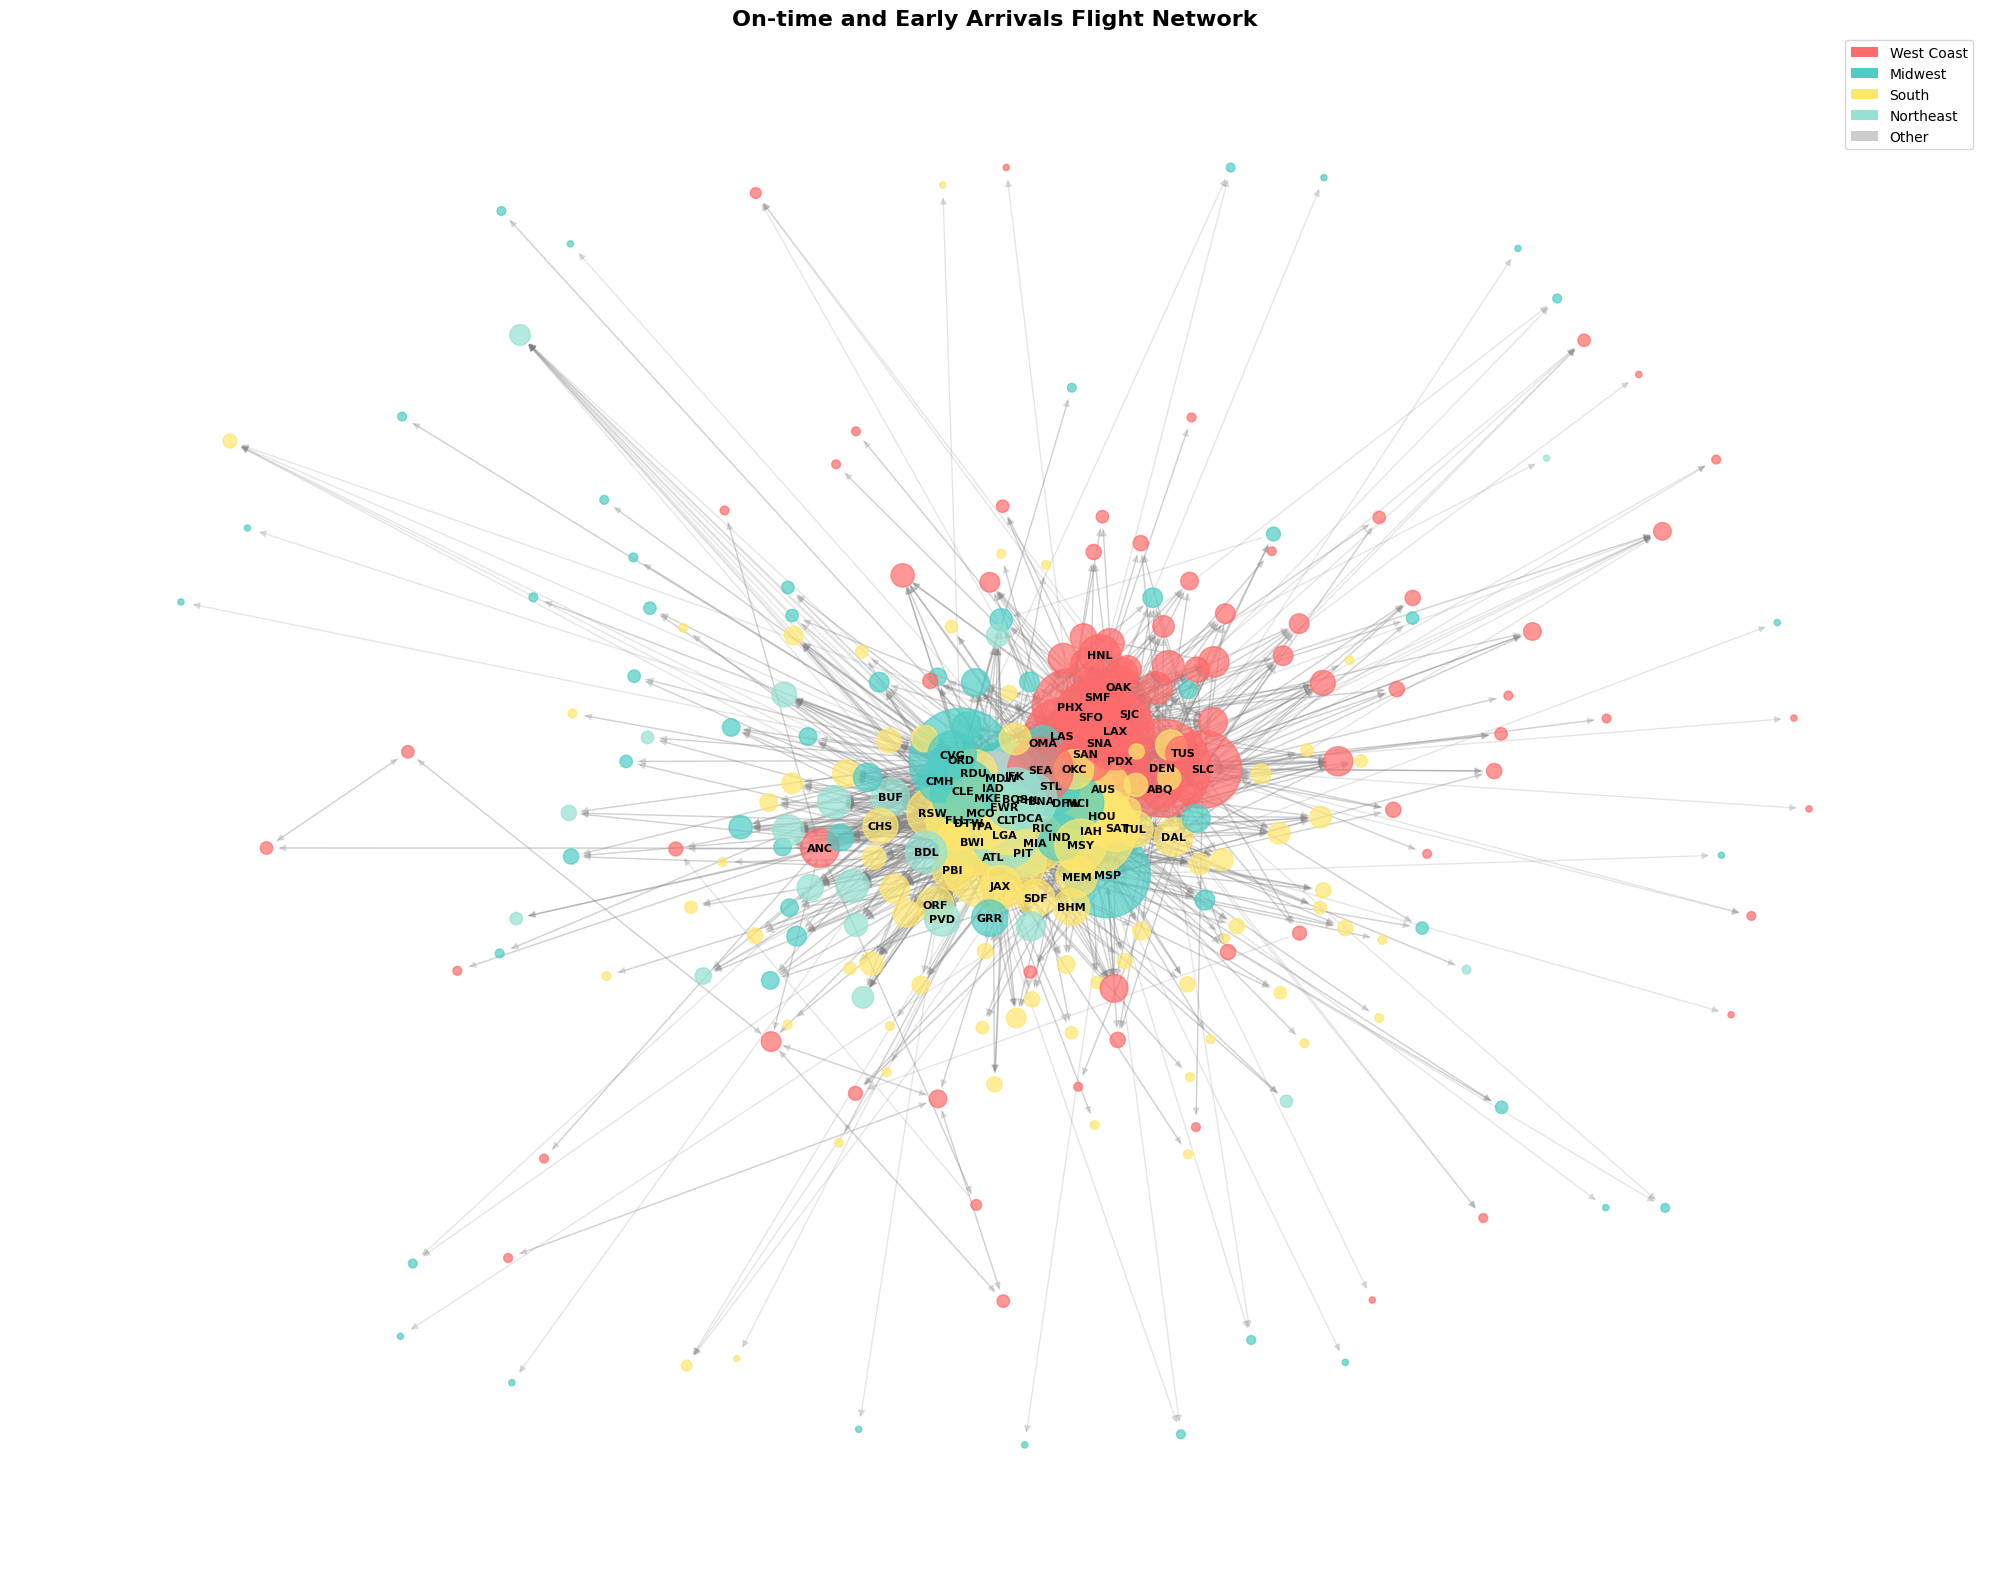

Total routes: 3931
Total airports: 279


In [0]:
# Chuyến bay Đúng giờ và Đến sớm - Đồ thị Mạng lười

# Truy vấn và chuyển sang pandas ngay lập tức
ontime_flights_pd = spark.sql("""
    SELECT src, dst as dest, COUNT(1) as count 
    FROM departureDelays_geo 
    WHERE delay <= 0 
    GROUP BY src, dst
""").toPandas()

airports_pd = spark.sql("""
    SELECT f.IATA, f.State 
    FROM airports_na f 
    JOIN tripIATA t ON t.IATA = f.IATA
""").toPandas()

# Gọi hàm trực quan hóa
# label_threshold=30: chỉ hiển nhãn cho sân bay có 30+ kết nối (giảm chồng chéo)
# Giảm xuống 0 nếu muốn hiển tất cả nhãn
plot_flight_network(
    ontime_flights_pd, 
    airports_pd,
    title="On-time and Early Arrivals Flight Network",
    figsize=(20, 16),  # Tăng kích thước lên rất lớn
    label_threshold=30  # Chỉ hiển nhãn cho các hub cực lớn
)

#### Chỉ Sân bay Trung tâm Lớn (Chế độ Lọc)
Chỉ hiển thị các sân bay có 20+ kết nối để trực quan hóa rõ ràng hơn

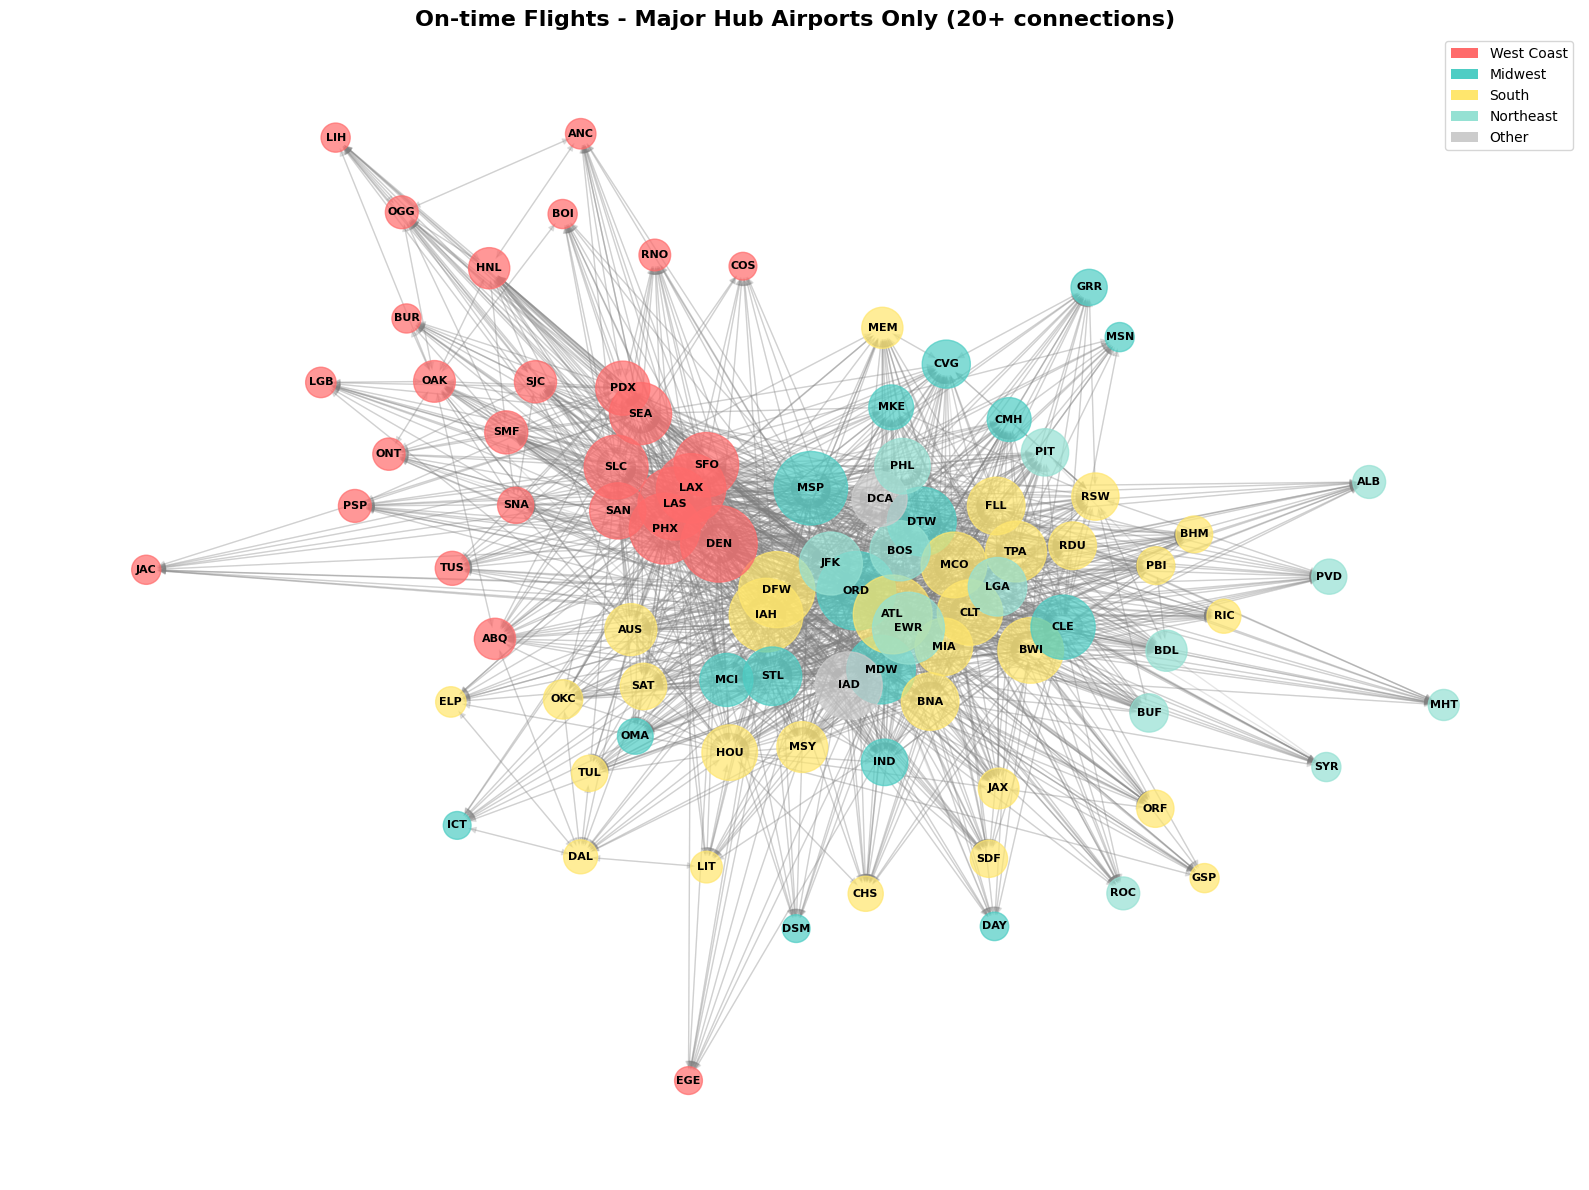

Total routes: 2873
Total airports: 90


In [0]:
# Chuyến bay Đúng giờ và Đến sớm - Chỉ các Trung tâm Lớn (20+ kết nối)
# Chế độ lọc này chỉ hiển thị các sân bay bận rộn nhất để trực quan hóa rõ ràng hơn

# Truy vấn và chuyển sang pandas ngay lập tức
ontime_flights_pd = spark.sql("""
    SELECT src, dst as dest, COUNT(1) as count 
    FROM departureDelays_geo 
    WHERE delay <= 0 
    GROUP BY src, dst
""").toPandas()

airports_pd = spark.sql("""
    SELECT f.IATA, f.State 
    FROM airports_na f 
    JOIN tripIATA t ON t.IATA = f.IATA
""").toPandas()

# Gọi hàm trực quan hóa với bộ lọc 20+ kết nối
plot_flight_network(
    ontime_flights_pd, 
    airports_pd,
    title="On-time Flights - Major Hub Airports Only (20+ connections)",
    figsize=(16, 12),
    min_connections=20
)

#### Trực quan hóa Chuyến bay Trễ Khởi hành từ Bờ biển Phía Tây

Lưu ý rằng hầu hết các chuyến bay trễ là với các thành phố miền Tây Hoa Kỳ


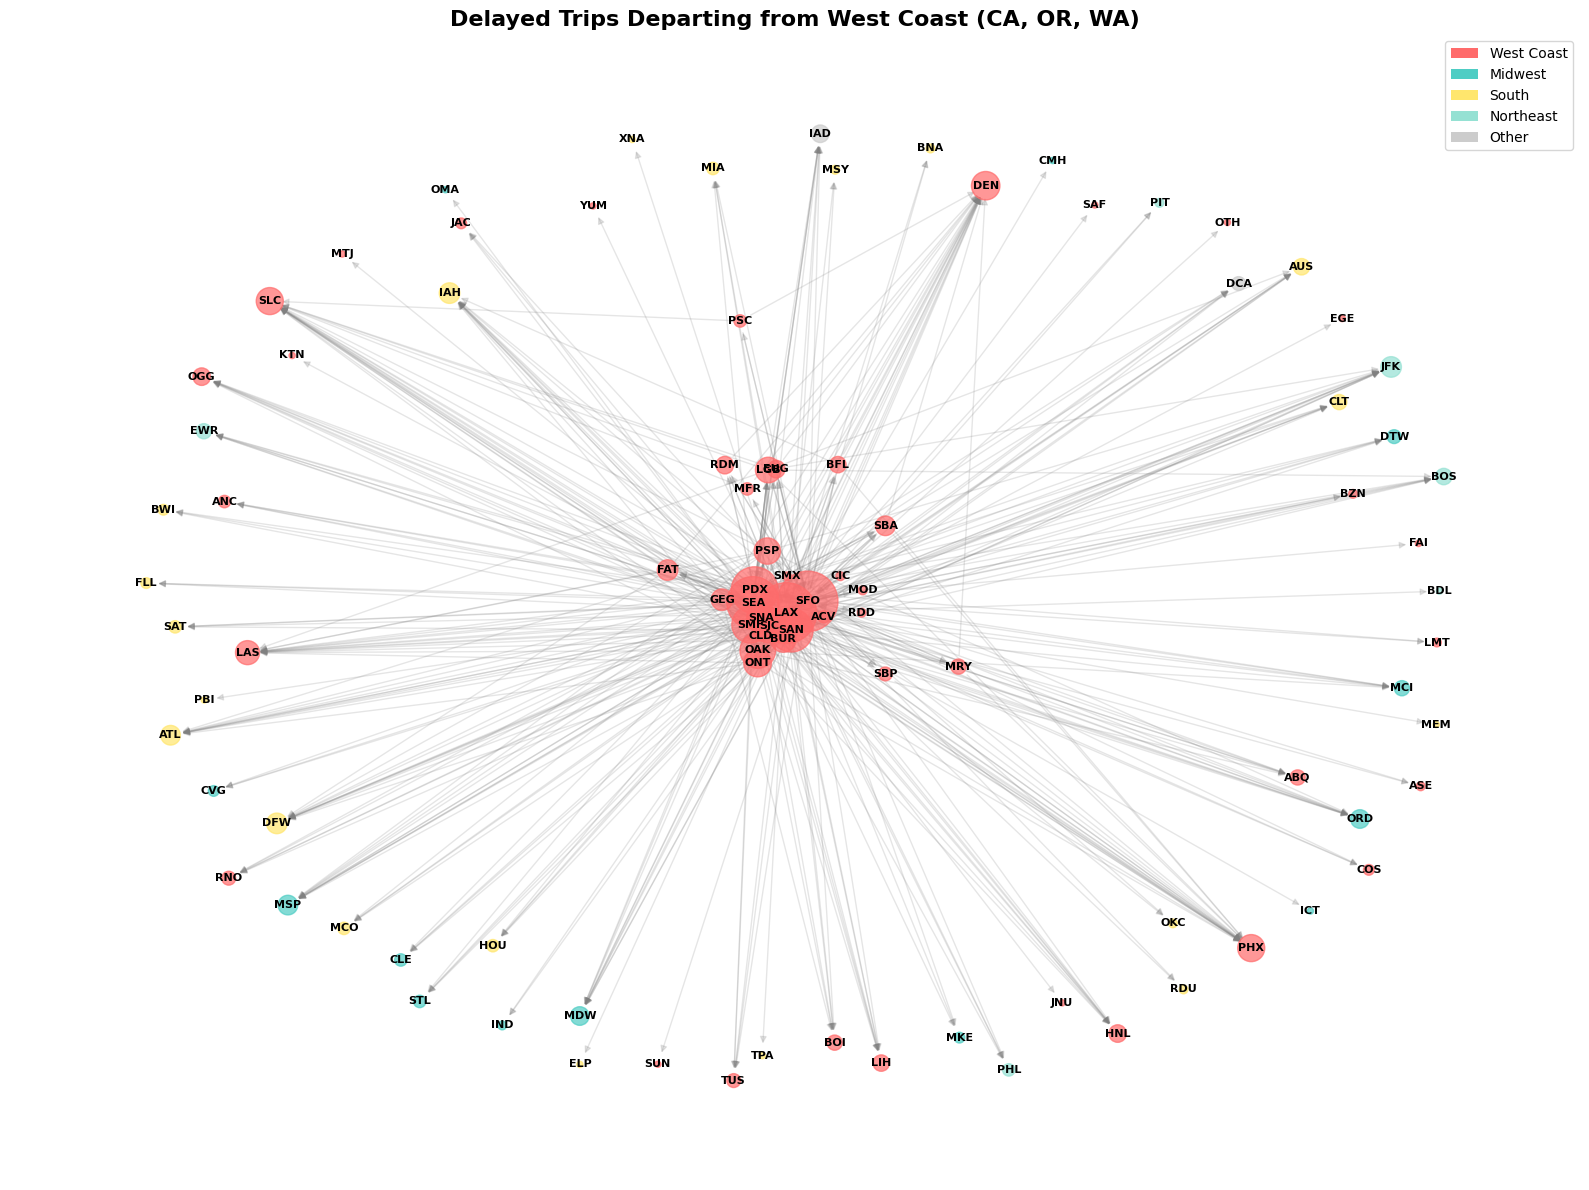

Total routes: 488
Total airports: 96


In [0]:
# Chuyến bay Trễ từ CA, OR, và/hoặc WA - Đồ thị Mạng lười

# Truy vấn và chuyển sang pandas ngay lập tức
delayed_westcoast_pd = spark.sql("""
    SELECT src, dst as dest, COUNT(1) as count 
    FROM departureDelays_geo 
    WHERE state_src IN ('CA', 'OR', 'WA') 
    AND delay > 0 
    GROUP BY src, dst
""").toPandas()

airports_pd = spark.sql("""
    SELECT f.IATA, f.State 
    FROM airports_na f 
    JOIN tripIATA t ON t.IATA = f.IATA
""").toPandas()

# Gọi hàm trực quan hóa
plot_flight_network(
    delayed_westcoast_pd, 
    airports_pd,
    title="Delayed Trips Departing from West Coast (CA, OR, WA)",
    figsize=(16, 12)
)

#### Trực quan hóa Tất cả Chuyến bay (từ bộ dữ liệu này)


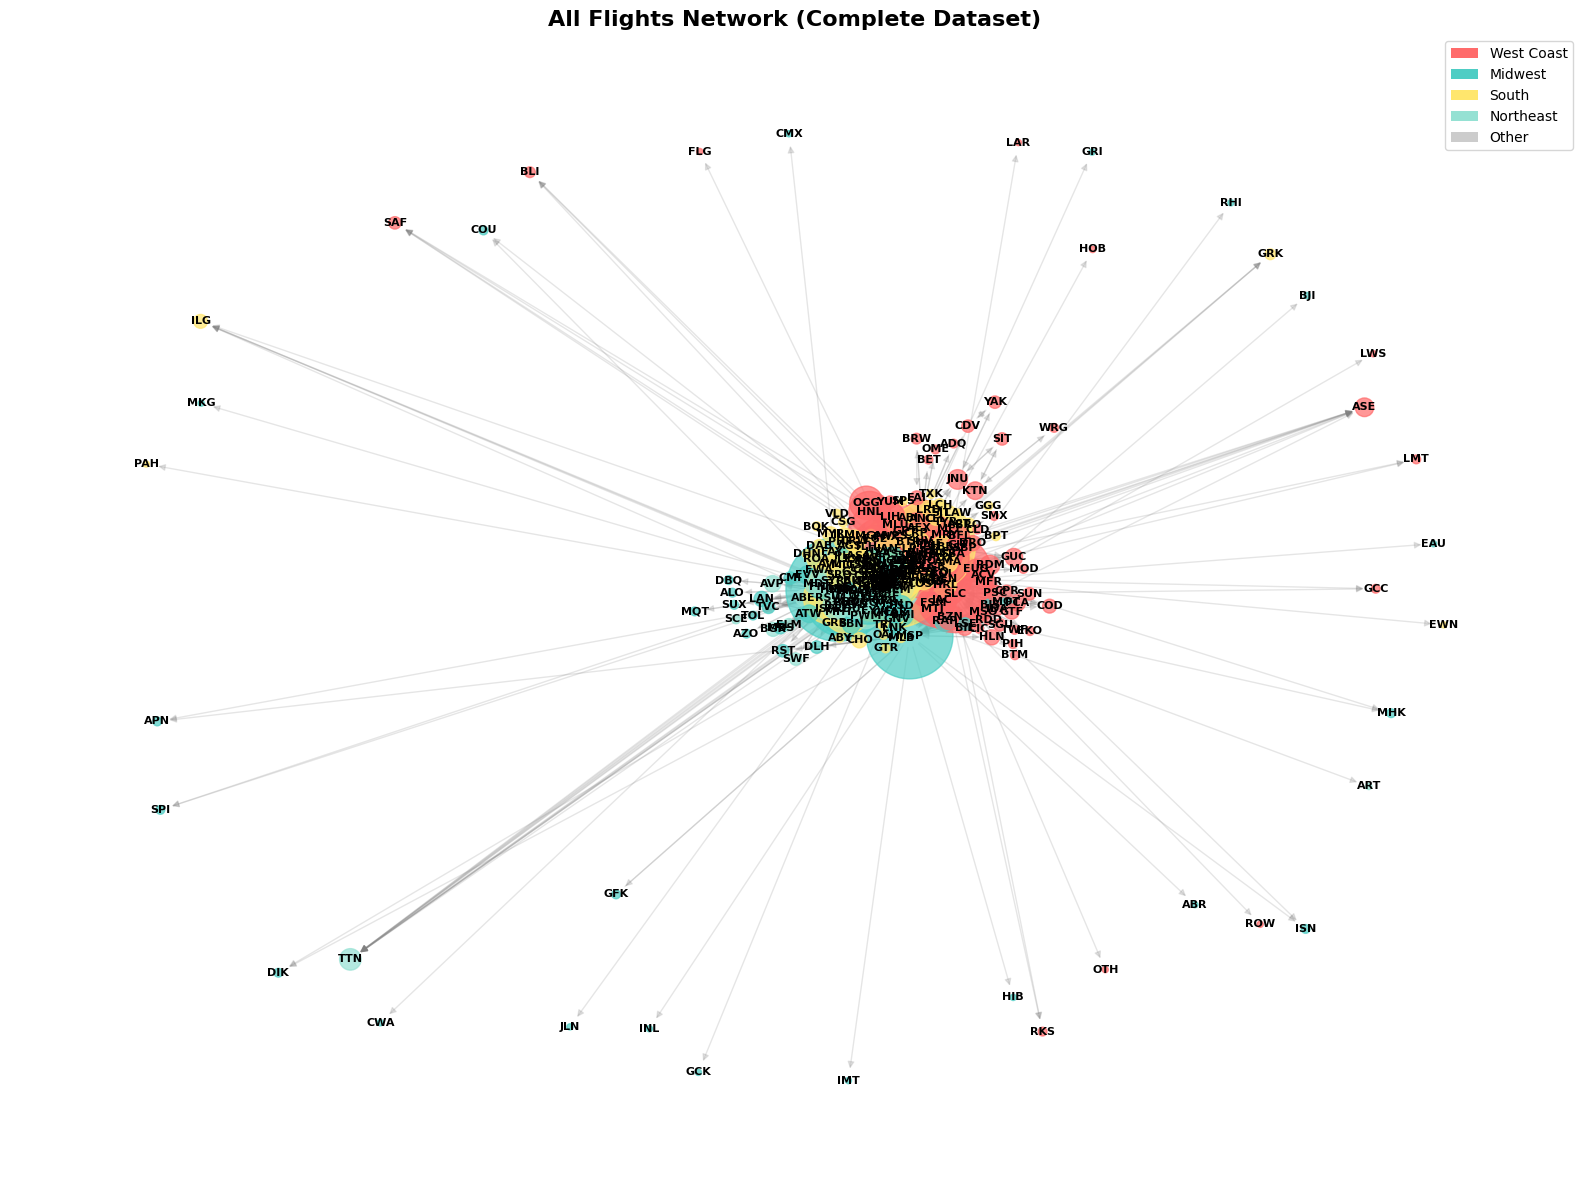

Total routes: 3976
Total airports: 279


In [0]:
# Tất cả Chuyến bay (từ Bộ dữ liệu DepartureDelays) - Đồ thị Mạng lười

# Truy vấn và chuyển sang pandas ngay lập tức
all_flights_pd = spark.sql("""
    SELECT src, dst as dest, COUNT(1) as count 
    FROM departureDelays_geo 
    GROUP BY src, dst
""").toPandas()

airports_pd = spark.sql("""
    SELECT f.IATA, f.State 
    FROM airports_na f 
    JOIN tripIATA t ON t.IATA = f.IATA
""").toPandas()

# Gọi hàm trực quan hóa
plot_flight_network(
    all_flights_pd, 
    airports_pd,
    title="All Flights Network (Complete Dataset)",
    figsize=(16, 12)
)

#### Trực quan hóa Bản đồ Địa lý
Bản đồ Hoa Kỳ tương tác hiển thị sân bay và khối lượng chuyến bay với độ chính xác địa lý

In [0]:
# Tải tọa độ sân bay từ nguồn bên ngoài
# Sử dụng bộ dữ liệu sân bay công khai với lat/lon
import requests
import io

# Tải tọa độ sân bay Hoa Kỳ
url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
response = requests.get(url)
airport_data = pd.read_csv(
    io.StringIO(response.text),
    header=None,
    names=['AirportID', 'Name', 'City', 'Country', 'IATA', 'ICAO', 'Latitude', 'Longitude', 
           'Altitude', 'Timezone', 'DST', 'TzDatabase', 'Type', 'Source']
)

# Lọc sân bay Hoa Kỳ và tạo bảng tìm kiếm
us_airports = airport_data[airport_data['Country'] == 'United States'].copy()
airport_coords = us_airports[['IATA', 'Latitude', 'Longitude', 'City']].dropna()

print(f"Loaded coordinates for {len(airport_coords)} US airports")

Loaded coordinates for 1512 US airports


In [0]:
# Tạo trực quan hóa bản đồ địa lý
import plotly.graph_objects as go
import pandas as pd

def create_geographic_map(flight_data, title="Bản đồ Mạng lưới Chuyến bay Hoa Kỳ", min_flights=0):
    """
    Tạo bản đồ địa lý tương tác hiển thị sân bay trên bản đồ Hoa Kỳ.
    
    Tham số:
    - flight_data: Spark DataFrame với các cột (src, dest, count)
    - title: Tiêu đề bản đồ
    - min_flights: Số chuyến bay tối thiểu để bao gồm sân bay
    """
    # Chuyển dữ liệu chuyến bay sang pandas
    df = flight_data.toPandas()
    
    # Tính tổng số chuyến bay cho mỗi sân bay
    src_flights = df.groupby('src')['count'].sum().reset_index()
    src_flights.columns = ['IATA', 'flights']
    
    dst_flights = df.groupby('dest')['count'].sum().reset_index()
    dst_flights.columns = ['IATA', 'flights']
    
    # Kết hợp và tính tổng
    all_flights = pd.concat([src_flights, dst_flights]).groupby('IATA')['flights'].sum().reset_index()
    
    # Lọc theo số chuyến bay tối thiểu
    if min_flights > 0:
        all_flights = all_flights[all_flights['flights'] >= min_flights]
    
    # Hợp nhất với tọa độ
    airport_data = all_flights.merge(airport_coords, on='IATA', how='inner', suffixes=('', '_coords'))
    
    # Lấy tiểu bang và khu vực để tô màu
    airports_df = airports.select('IATA', 'State', 'City').toPandas()
    airport_data = airport_data.merge(airports_df, on='IATA', how='left', suffixes=('_coords', '_airports'))
    
    # Áp dụng tô màu theo khu vực
    airport_data['region_color'] = airport_data['State'].apply(get_region_color)
    airport_data['region'] = airport_data['State'].apply(lambda s: 
        'West' if s in ['CA', 'OR', 'WA', 'NV', 'AZ', 'UT', 'ID', 'MT', 'WY', 'CO', 'NM', 'AK', 'HI'] else
        'Midwest' if s in ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'] else
        'South' if s in ['TX', 'OK', 'AR', 'LA', 'MS', 'AL', 'TN', 'KY', 'FL', 'GA', 'SC', 'NC', 'VA', 'WV', 'MD', 'DE'] else
        'Northeast' if s in ['PA', 'NY', 'NJ', 'CT', 'RI', 'MA', 'VT', 'NH', 'ME'] else
        'Other'
    )
    
    # Xác định tên cột City chính xác sau khi hợp nhất
    city_col = 'City' if 'City' in airport_data.columns else (
        'City_coords' if 'City_coords' in airport_data.columns else 'City_airports'
    )
    
    # Tạo hình
    fig = go.Figure()
    
    # Thêm scatter cho mỗi khu vực (để hiển chú giải)
    regions = {'West': '#FF6B6B', 'Midwest': '#4ECDC4', 'South': '#FFD93D', 
               'Northeast': '#95E1D3', 'Other': '#C7CEEA'}
    
    for region_name, color in regions.items():
        region_data = airport_data[airport_data['region'] == region_name]
        if len(region_data) > 0:
            fig.add_trace(go.Scattergeo(
                lon=region_data['Longitude'],
                lat=region_data['Latitude'],
                text=region_data.apply(lambda row: 
                    f"{row['IATA']}<br>{row[city_col]}<br>Flights: {row['flights']:,}", axis=1),
                mode='markers',
                name=region_name,
                marker=dict(
                    size=region_data['flights'] / 1000,  # Scale down for visibility
                    color=color,
                    line=dict(width=1, color='white'),
                    sizemode='diameter',
                    sizemin=4
                ),
                hoverinfo='text'
            ))
    
    # Cập nhật bố cục cho bản đồ tập trung vào Hoa Kỳ
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor='center', font=dict(size=18)),
        geo=dict(
            scope='usa',
            projection_type='albers usa',
            showland=True,
            landcolor='rgb(243, 243, 243)',
            coastlinecolor='rgb(204, 204, 204)',
            showlakes=True,
            lakecolor='rgb(230, 245, 255)',
            subunitcolor='rgb(217, 217, 217)',
        ),
        height=700,
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor="rgba(255,255,255,0.8)"
        )
    )
    
    # Hiển thị hình
    display(fig)

print("Geographic map function ready!")

Geographic map function ready!


In [0]:
# Bản đồ Địa lý: Tất cả Chuyến bay
create_geographic_map(
    all_flights,
    title="US Airport Network - All Flights",
    min_flights=5000  # Only show airports with 5000+ total flights
)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-fac8d004-1515-4b65-a5f0-601d25fa34f5/lib/python3.11/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [0]:
# Bản đồ Địa lý: Chuyến bay Đúng giờ
create_geographic_map(
    ontime_flights,
    title="US Airport Network - On-time & Early Arrivals",
    min_flights=3000
)

In [0]:
# Bản đồ Địa lý: Chuyến bay Trễ từ Bờ biển Phía Tây
create_geographic_map(
    delayed_westcoast,
    title="Delayed Flights from West Coast (CA, OR, WA)",
    min_flights=500
)